In [128]:
import pandas as pd

In [129]:
df = pd.read_csv('./../data/IMDB Dataset.csv')

In [130]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [131]:
df.sentiment.value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [132]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [133]:
df.isna().sum()

review       0
sentiment    0
dtype: int64

In [134]:
df.duplicated().sum()

np.int64(418)

In [135]:
df.drop_duplicates(keep='first', inplace=True)

In [136]:
df.shape

(49582, 2)

In [137]:
target_names = ['negative', 'positive']
label_mapping = {'negative': 0, 'positive': 1}

X = df.review
y = df.sentiment.map(label_mapping)

In [138]:
X[4]

'Petter Mattei\'s "Love in the Time of Money" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. This is a movie that seems to be telling us what money, power and success do to people in the different situations we encounter. <br /><br />This being a variation on the Arthur Schnitzler\'s play about the same theme, the director transfers the action to the present time New York where all these different characters meet and connect. Each one is connected in one way, or another to the next person, but no one seems to know the previous point of contact. Stylishly, the film has a sophisticated luxurious look. We are taken to see how these people live and the world they live in their own habitat.<br /><br />The only thing one gets out of all these souls in the picture is the different stages of loneliness each one inhabits. A big city is not exactly the best place in which human relations find sincere fulfillment, as one discerns is the case wit

## Text Processing

In [139]:
import re
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [140]:
lemmatizer = WordNetLemmatizer()

In [141]:
def text_processor(text):
    
    text = text.lower()
    
    # Removing HTML Tags
    text = re.sub(r"<.+?>", "", text)
    
    # Removing URLs
    text = re.sub(r"(https?:\/\/\S+)|(www.\S+)", "", text)
    
    # Removing Puncuation and Sepcial Chars
    text = re.sub(r"[^\w\d\s]", " ", text)
    
    # Removing Spaces
    text = text.strip()
    
    # Removing Stop words
    text = [word for word in text.split() if (word not in ENGLISH_STOP_WORDS) and (len(word) > 1) ]
    text = " ".join(text)
    
    # Lemmatization {Optional}
    text = lemmatizer.lemmatize(text)
    
    return text

In [142]:
cleaned_reviews = X.apply(text_processor).to_numpy()

In [143]:
cleaned_reviews[5]

'probably time favorite movie story selflessness sacrifice dedication noble cause preachy boring just gets old despite having seen 15 times 25 years paul lukas performance brings tears eyes bette davis truly sympathetic roles delight kids grandma says like dressed midgets children makes fun watch mother slow awakening happening world roof believable startling dozen thumbs movie'

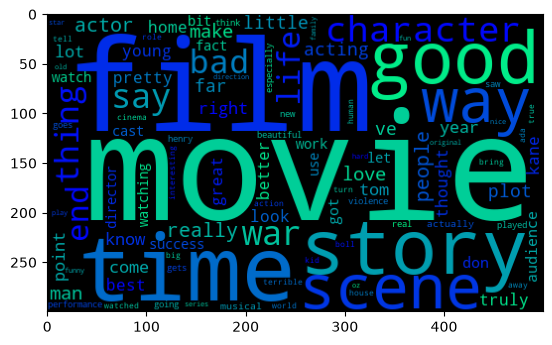

In [144]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

cloud = WordCloud(
    colormap = "winter", max_words=100, width=500, height=300
)
image = cloud.generate(" ".join(cleaned_reviews[:50]))

plt.imshow(image)